In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")  # so we can import from vision/
from vision.constants import LABELS

sns.set_theme(style="whitegrid")

train_df = pd.read_csv("../data/splits/train.csv")
val_df = pd.read_csv("../data/splits/val.csv")
test_df = pd.read_csv("../data/splits/test.csv")

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (7035, 25)
Val:   (1500, 25)
Test:  (1502, 25)


In [10]:
print("=== TRAIN SET OVERVIEW ===")
print(f"Total images: {len(train_df)}")
print(f"Unique patients: {train_df['Patient ID'].nunique()}")
print(f"Avg images per patient: {len(train_df) / train_df['Patient ID'].nunique():.2f}")
print()
print("Gender distribution:")
print(train_df['Patient Gender'].value_counts())
print()
print("Age stats:")
print(train_df['Patient Age'].describe())
print()
print("View Position distribution:")
print(train_df['View Position'].value_counts())

=== TRAIN SET OVERVIEW ===
Total images: 7035
Unique patients: 1929
Avg images per patient: 3.65

Gender distribution:
Patient Gender
M    3768
F    3267
Name: count, dtype: int64

Age stats:
count    7035.000000
mean       48.174271
std        16.377783
min         2.000000
25%        38.000000
50%        49.000000
75%        59.000000
max        92.000000
Name: Patient Age, dtype: float64

View Position distribution:
View Position
PA    4527
AP    2508
Name: count, dtype: int64


In [11]:
import os
os.makedirs("../outputs/figures", exist_ok=True)
print("Folder ready:", os.path.exists("../outputs/figures"))

Folder ready: True


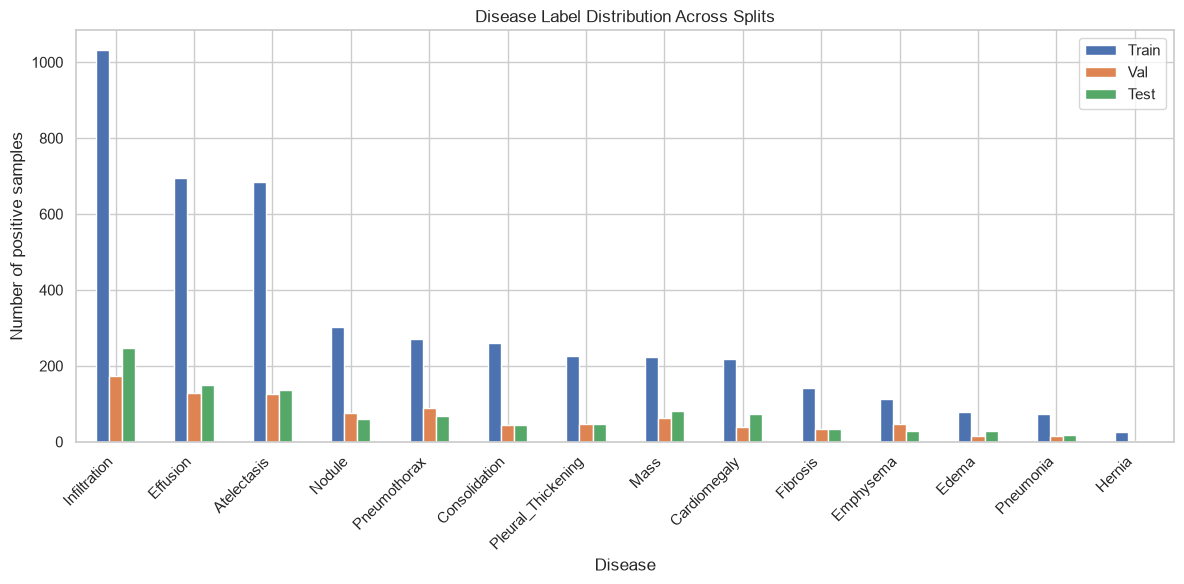

                    Train  Val  Test
Infiltration         1032  173   248
Effusion              696  128   150
Atelectasis           684  125   137
Nodule                303   75    59
Pneumothorax          272   89    69
Consolidation         261   44    45
Pleural_Thickening    225   47    46
Mass                  223   62    81
Cardiomegaly          218   40    72
Fibrosis              142   34    34
Emphysema             114   47    29
Edema                  78   14    28
Pneumonia              74   15    18
Hernia                 26    1     2


In [12]:
label_counts = pd.DataFrame({
    "Train": train_df[LABELS].sum(),
    "Val": val_df[LABELS].sum(),
    "Test": test_df[LABELS].sum(),
})
label_counts = label_counts.sort_values("Train", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
label_counts.plot(kind="bar", ax=ax)
ax.set_title("Disease Label Distribution Across Splits")
ax.set_ylabel("Number of positive samples")
ax.set_xlabel("Disease")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png", dpi=150)
plt.show()

print(label_counts)

In [ ]:
**Observation:** Class proportions are roughly consistent across splits, with some
natural variance from patient-level splitting (e.g. Cardiomegaly is proportionally
higher in test). Hernia is extremely rare (26/1929 patients in train) and its
count will be noisy across splits due to small sample size — this rarity is why
focal loss will be needed during training (Phase 7).

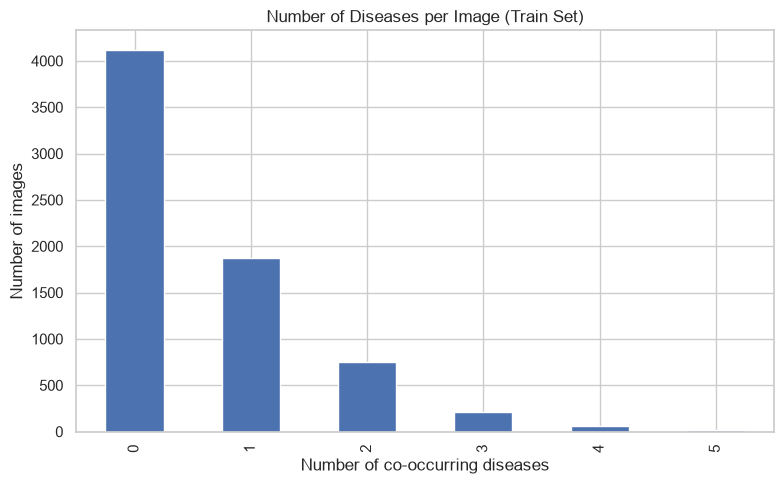

num_labels
0    4122
1    1870
2     749
3     215
4      60
5      19
Name: count, dtype: int64

Images with 'No Finding' (0 labels): 4122
Images with 2+ co-occurring diseases: 1043


In [13]:
train_df["num_labels"] = train_df[LABELS].sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
train_df["num_labels"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Number of Diseases per Image (Train Set)")
ax.set_xlabel("Number of co-occurring diseases")
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.savefig("../outputs/figures/multilabel_frequency.png", dpi=150)
plt.show()

print(train_df["num_labels"].value_counts().sort_index())
print(f"\nImages with 'No Finding' (0 labels): {(train_df['num_labels']==0).sum()}")
print(f"Images with 2+ co-occurring diseases: {(train_df['num_labels']>=2).sum()}")

In [14]:
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    num_labels = df[LABELS].sum(axis=1)
    no_finding_pct = (num_labels == 0).mean() * 100
    print(f"{name}: {no_finding_pct:.1f}% No Finding, "
          f"{len(df)} images, {df['Patient ID'].nunique()} patients")

Train: 58.6% No Finding, 7035 images, 1929 patients
Val: 61.1% No Finding, 1500 images, 464 patients
Test: 56.5% No Finding, 1502 images, 383 patients


In [ ]:
## EDA Summary

- **Dataset**: 10,037 images across 4,776 unique patients (3 of 12 NIH archives)
- **Splits**: 70/15/15 train/val/test by patient, verified zero patient leakage
- **Class balance**: highly imbalanced — Infiltration (1,032 positive in train) vs
  Hernia (26 positive in train), consistent with known ChestX-ray14 properties.
  Will require focal loss (Phase 7) to handle this during training.
- **Multi-label structure**: 58.6% train images have no finding, 27% have exactly
  one, ~15% have two or more co-occurring diseases — confirms multi-label
  (not single-label) classification is the right approach.
- **Split consistency**: No Finding rate stays within 56-61% across all three
  splits — no red flags suggesting a skewed split.

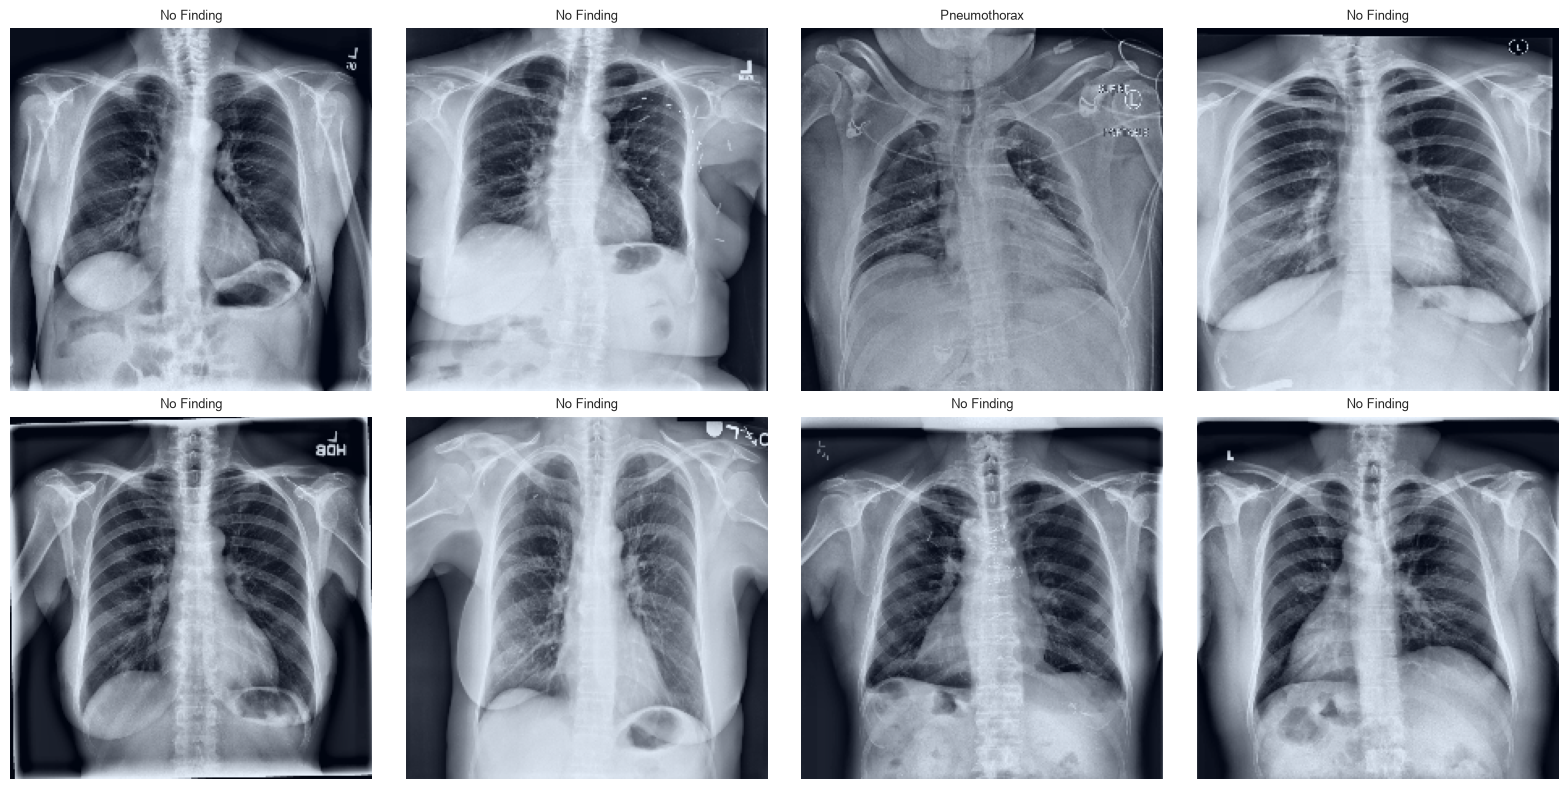

In [15]:
import sys
sys.path.append("..")
from vision.preprocessing import build_dataset
import matplotlib.pyplot as plt

train_ds = build_dataset("../data/splits/train.csv", training=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for images, labels in train_ds.take(1):
    for i in range(8):
        ax = axes[i // 4, i % 4]
        # Un-normalize just for display purposes (rough approximation)
        img_display = images[i].numpy()
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
        ax.imshow(img_display)
        active_labels = [LABELS[j] for j in range(14) if labels[i][j] == 1]
        title = ", ".join(active_labels) if active_labels else "No Finding"
        ax.set_title(title, fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/sample_batch_preview.png", dpi=150)
plt.show()